In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import itertools, random, time
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [2]:
# Q1 : Chargement et statistiques descriptives
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

print(f"Nombre d'exemples : {df.shape[0]}")
print(f"Nombre de features : {df.shape[1] - 1}")
print(f"Noms des features : {california.feature_names}\n")
print("=== 5 premières lignes ===")
print(df.head(), "\n")
print("=== Statistiques descriptives ===")
print(df.describe())


Nombre d'exemples : 20640
Nombre de features : 8
Noms des features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

=== 5 premières lignes ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422   

=== Statistiques descriptives ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  2

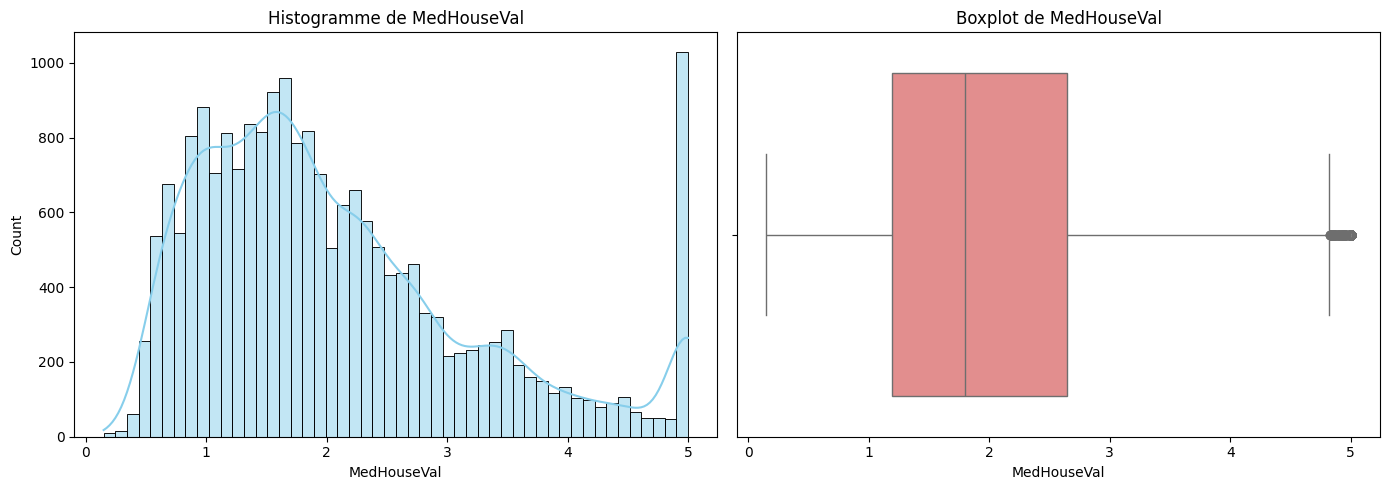

In [3]:
# Q2 : Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogramme de MedHouseVal')
sns.boxplot(x=df['MedHouseVal'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot de MedHouseVal')
plt.tight_layout()
plt.savefig('distribution_target.png', dpi=120)
plt.show()

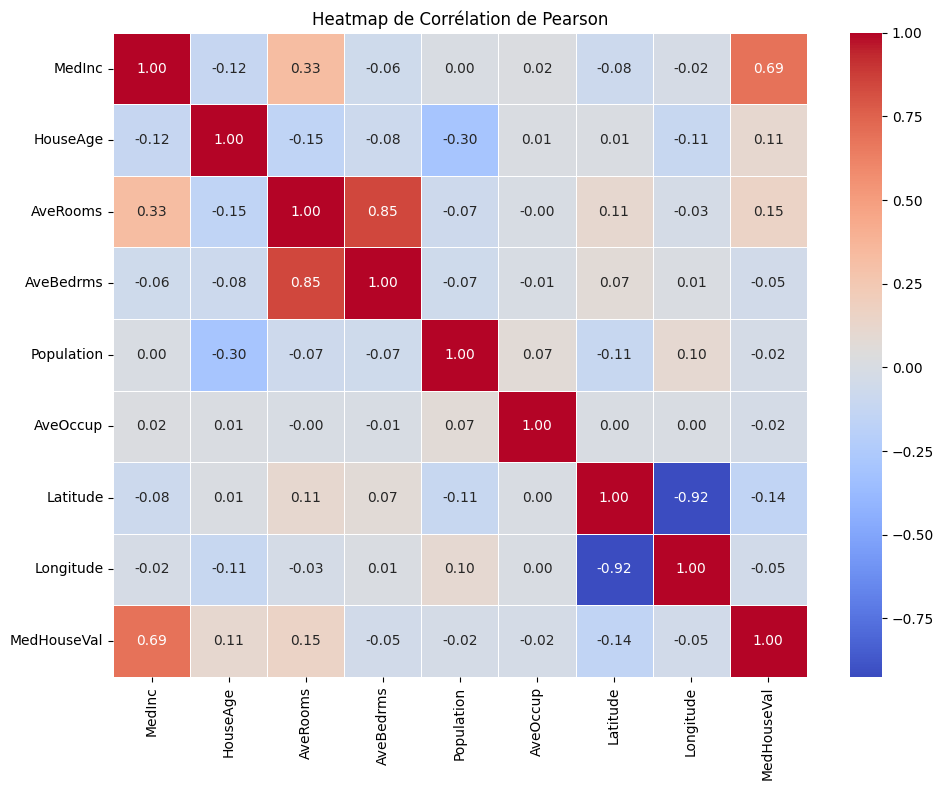

In [4]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Corrélation de Pearson')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

In [5]:
df['target_bins'] = pd.cut(df['MedHouseVal'], bins=5, labels=False)

X = df.drop(columns=['MedHouseVal', 'target_bins']).values
y = df['MedHouseVal'].values.reshape(-1, 1)
bins = df['target_bins'].values

X_train, X_temp, y_train, y_temp, _, bins_temp = train_test_split(
    X, y, bins, test_size=0.30, random_state=42, stratify=bins
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=bins_temp
)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [8]:
train_dataset = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val_scaled, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


In [9]:
xb, yb = next(iter(train_loader))
print("\n=== Vérification des dimensions après pipeline ===")
print(f'X batch: {xb.shape} | y batch: {yb.shape}')
print(f'X mean: {xb.mean().item():.4f} | X std: {xb.std().item():.4f}')


=== Vérification des dimensions après pipeline ===
X batch: torch.Size([64, 8]) | y batch: torch.Size([64, 1])
X mean: 0.0341 | X std: 1.1984


In [10]:
class DeepFFN(nn.Module):
    """
    Réseau de neurones Feedforward profond, modulaire et configurable.
    Intègre la Batch Normalization, le Dropout et une initialisation automatique.
    """
    def __init__(self, input_dim=8, hidden_dims=[128, 64, 32], output_dim=1, 
                 activation='relu', use_bn=True, dropout_rate=0.2):
        super(DeepFFN, self).__init__()
        
        self.layers = nn.ModuleList()
        current_dim = input_dim
        self.activation_name = activation.lower()
        
        # Construction dynamique des couches cachées
        for h_dim in hidden_dims:
            # 1. Couche Linéaire : Y = X * W^T + b
            self.layers.append(nn.Linear(current_dim, h_dim))
            
            # 2. Batch Normalization (optionnelle, appliquée avant l'activation ou juste après)
            if use_bn:
                self.layers.append(nn.BatchNorm1d(h_dim))
                
            # 3. Fonction d'activation
            self.layers.append(self.get_activation(self.activation_name))
            
            # 4. Régularisation par Dropout (optionnelle)
            if dropout_rate > 0.0:
                self.layers.append(nn.Dropout(dropout_rate))
                
            current_dim = h_dim
            
        # Couche de sortie finale (Régression -> pas d'activation finale)
        self.output_layer = nn.Linear(current_dim, output_dim)
        
        # Application automatique de la stratégie d'initialisation des poids
        self.init_weights()

    def get_activation(self, name):
        """Sélecteur de fonction d'activation de manière dynamique."""
        if name == 'relu': return nn.ReLU()
        elif name == 'tanh': return nn.Tanh()
        elif name == 'leaky_relu': return nn.LeakyReLU()
        elif name == 'elu': return nn.ELU()
        elif name == 'selu': return nn.SELU()
        else: raise ValueError(f"Activation '{name}' non supportée par le modèle.")

    def init_weights(self):
        """
        Q2 : Stratégie d'initialisation stricte des poids (He / Xavier).
        Évite la disparition ou l'explosion du gradient dès la première époque.
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Si l'activation utilise des variantes de ReLU -> Initialisation de He (Kaiming)
                if self.activation_name in ['relu', 'leaky_relu', 'elu']:
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                # Pour Tanh ou d'autres fonctions saturantes -> Initialisation de Xavier (Glorot)
                else:
                    nn.init.xavier_uniform_(m.weight)
                    
                # Initialisation des biais à 0 (recommandé)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """Passage vers l'avant dans toutes les couches imbriquées."""
        for layer in self.layers:
            x = layer(x)
        return self.output_layer(x)

In [20]:
model = DeepFFN()
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres entraînables : {total_params:,}')
# Test forward pass
xb, _ = next(iter(train_loader))
out = model(xb)
print(f'Sortie : {out.shape}') # [64, 1]
print(f'Plage : [{out.min().item():.3f}, {out.max().item():.3f}]')

DeepFFN(
  (layers): ModuleList(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Paramètres entraînables : 11,969
Sortie : torch.Size([64, 1])
Plage : [-0.860, 2.420]


In [16]:
# =====================================================================
# Partie 2.2 : Gradient Clipping et Boucle d'Entraînement
# =====================================================================

def train_one_epoch(model, loader, optimizer, criterion, clip_value=1.0):
    """
    Q4 : Entraîne le modèle sur une unique époque (un passage complet des données).
    Calcule la perte, rétropropage, surveille la norme et applique le clipping.
    """
    # 1. Passage du modèle en mode entraînement (active le Dropout et la BatchNorm)
    model.train()
    
    total_loss = 0.0
    total_grad_norm = 0.0
    n_samples = 0
    
    # 2. Boucle sur chaque mini-batch fourni par le DataLoader
    for xb, yb in loader:
        # Réinitialisation des gradients calculés à l'étape précédente
        optimizer.zero_grad()
        
        # Forward pass : calcul de la prédiction du modèle
        pred = model(xb)
        
        # Calcul de la perte locale (perte quadratique moyenne - MSE)
        loss = criterion(pred, yb)
        
        # Backward pass : calcul automatique des gradients par rétropropagation
        loss.backward()
        
        # 3 & 4. Récupération de la norme globale du gradient AVANT le clipping pour le monitoring,
        # puis application du Gradient Clipping pour stabiliser l'apprentissage.
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        total_grad_norm += grad_norm.item()
        
        # Mise à jour des poids du modèle à l'aide de l'optimiseur
        optimizer.step()
        
        # Accumulation de la perte pondérée par la taille du batch courant
        total_loss += loss.item() * len(xb)
        n_samples += len(xb)
        
    # Retourne la perte moyenne et la norme globale moyenne du gradient sur l'époque
    return total_loss / n_samples, total_grad_norm / len(loader)




In [17]:
def evaluate(model, loader, criterion):
    """
    Q5 : Évalue les performances du modèle sur un DataLoader (Validation ou Test).
    Retourne les métriques réglementaires : MSE, MAE et R².
    """
    # Passage du modèle en mode évaluation (désactive le Dropout et figée la BatchNorm)
    model.eval()
    
    preds, targets = [], []
    
    # Désactivation du calcul des gradients (économie majeure de mémoire vive et de calcul)
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            
            # Stockage des prédictions et des vraies valeurs sous forme de tableaux NumPy
            preds.append(pred.numpy())
            targets.append(yb.numpy())
            
    # Reconstruction des matrices complètes par empilement vertical
    preds = np.vstack(preds)
    targets = np.vstack(targets)
    
    # Calcul des trois métriques exigées à l'aide de scikit-learn
    mse = mean_squared_error(targets, preds)
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    
    return mse, mae, r2


In [18]:
def train_model(model, train_loader, val_loader, config):
    """
    Q6 : Boucle d'entraînement complète orchestrant l'apprentissage sur plusieurs époques.
    Gère l'optimiseur Adam, le ReduceLROnPlateau, l'Early Stopping et l'historique.
    """
    # Création de l'optimiseur Adam avec le taux d'apprentissage (lr) et la régularisation L2 (weight_decay)
    optimizer = optim.Adam(
        model.parameters(), 
        lr=config['lr'], 
        weight_decay=config.get('weight_decay', 0.0)
    )
    
    # Création du scheduler ReduceLROnPlateau (divise le LR par 2 si la val_loss stagne pendant 10 époques)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        patience=10, 
        factor=0.5, 
        min_lr=1e-6
    )
    
    # Définition de la fonction de coût de référence
    criterion = nn.MSELoss()
    clip_value = config.get('clip_value', 1.0)
    
    # Dictionnaire destiné à enregistrer l'évolution des métriques époque par époque
    history = {
        'train_mse': [], 'val_mse': [], 'val_mae': [], 
        'val_r2': [], 'lr': [], 'grad_norm': []
    }
    
    best_val_mse = float('inf')
    patience_es = config.get('early_stopping_patience', 20)
    no_improve_epochs = 0
    start_time = time.time()
    
    # Lancement de la boucle sur les époques
    for epoch in range(config.get('epochs', 200)):
        
        # Exécution d'une époque d'entraînement
        train_mse, avg_gnorm = train_one_epoch(model, train_loader, optimizer, criterion, clip_value)
        
        # Évaluation sur les données de validation
        val_mse, val_mae, val_r2 = evaluate(model, val_loader, criterion)
        
        # Mise à jour du planificateur de Learning Rate basé sur l'erreur de validation
        scheduler.step(val_mse)
        
        # Sauvegarde des données dans l'historique
        history['train_mse'].append(train_mse)
        history['val_mse'].append(val_mse)
        history['val_mae'].append(val_mae)
        history['val_r2'].append(val_r2)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['grad_norm'].append(avg_gnorm)
        
        # Logique d'Early Stopping et de sauvegarde du meilleur modèle
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            no_improve_epochs = 0
            # Sauvegarde des états du modèle (state_dict) pour le meilleur score trouvé
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            no_improve_epochs += 1
            
        # Affichage des métriques toutes les 20 époques (suivi demandé en Q6)
        if (epoch + 1) % 20 == 0:
            print(f"Ep [{epoch+1:3d}] | tr MSE={train_mse:.4f} | val MSE={val_mse:.4f} | R²={val_r2:.4f} | lr={optimizer.param_groups[0]['lr']:.6f}")
            
        # Déclenchement de l'arrêt précoce si aucune amélioration constatée sur la durée de patience
        if no_improve_epochs >= patience_es:
            print(f" Early stopping à l'epoch {epoch+1}")
            break
            
    # Temps total écoulé pour l'entraînement
    training_time = time.time() - start_time
    
    return history, best_val_mse, training_time


=== Préparation de la Configuration Baseline ===
Lancement de l'apprentissage du modèle Baseline...
Ep [ 20] | tr MSE=0.3910 | val MSE=0.3929 | R²=0.7009 | lr=0.001000
Ep [ 40] | tr MSE=0.3598 | val MSE=0.3168 | R²=0.7589 | lr=0.001000
Ep [ 60] | tr MSE=0.3570 | val MSE=0.5517 | R²=0.5801 | lr=0.001000
Ep [ 80] | tr MSE=0.3488 | val MSE=0.3330 | R²=0.7465 | lr=0.001000
Ep [100] | tr MSE=0.3350 | val MSE=0.2738 | R²=0.7916 | lr=0.000250
Ep [120] | tr MSE=0.3259 | val MSE=0.3968 | R²=0.6980 | lr=0.000250
 Early stopping à l'epoch 135

[Fin de l'Entraînement]
Meilleur score trouvé (Validation MSE) : 0.2688
Temps de calcul total : 118.0 secondes

Création et sauvegarde des courbes d'apprentissage...


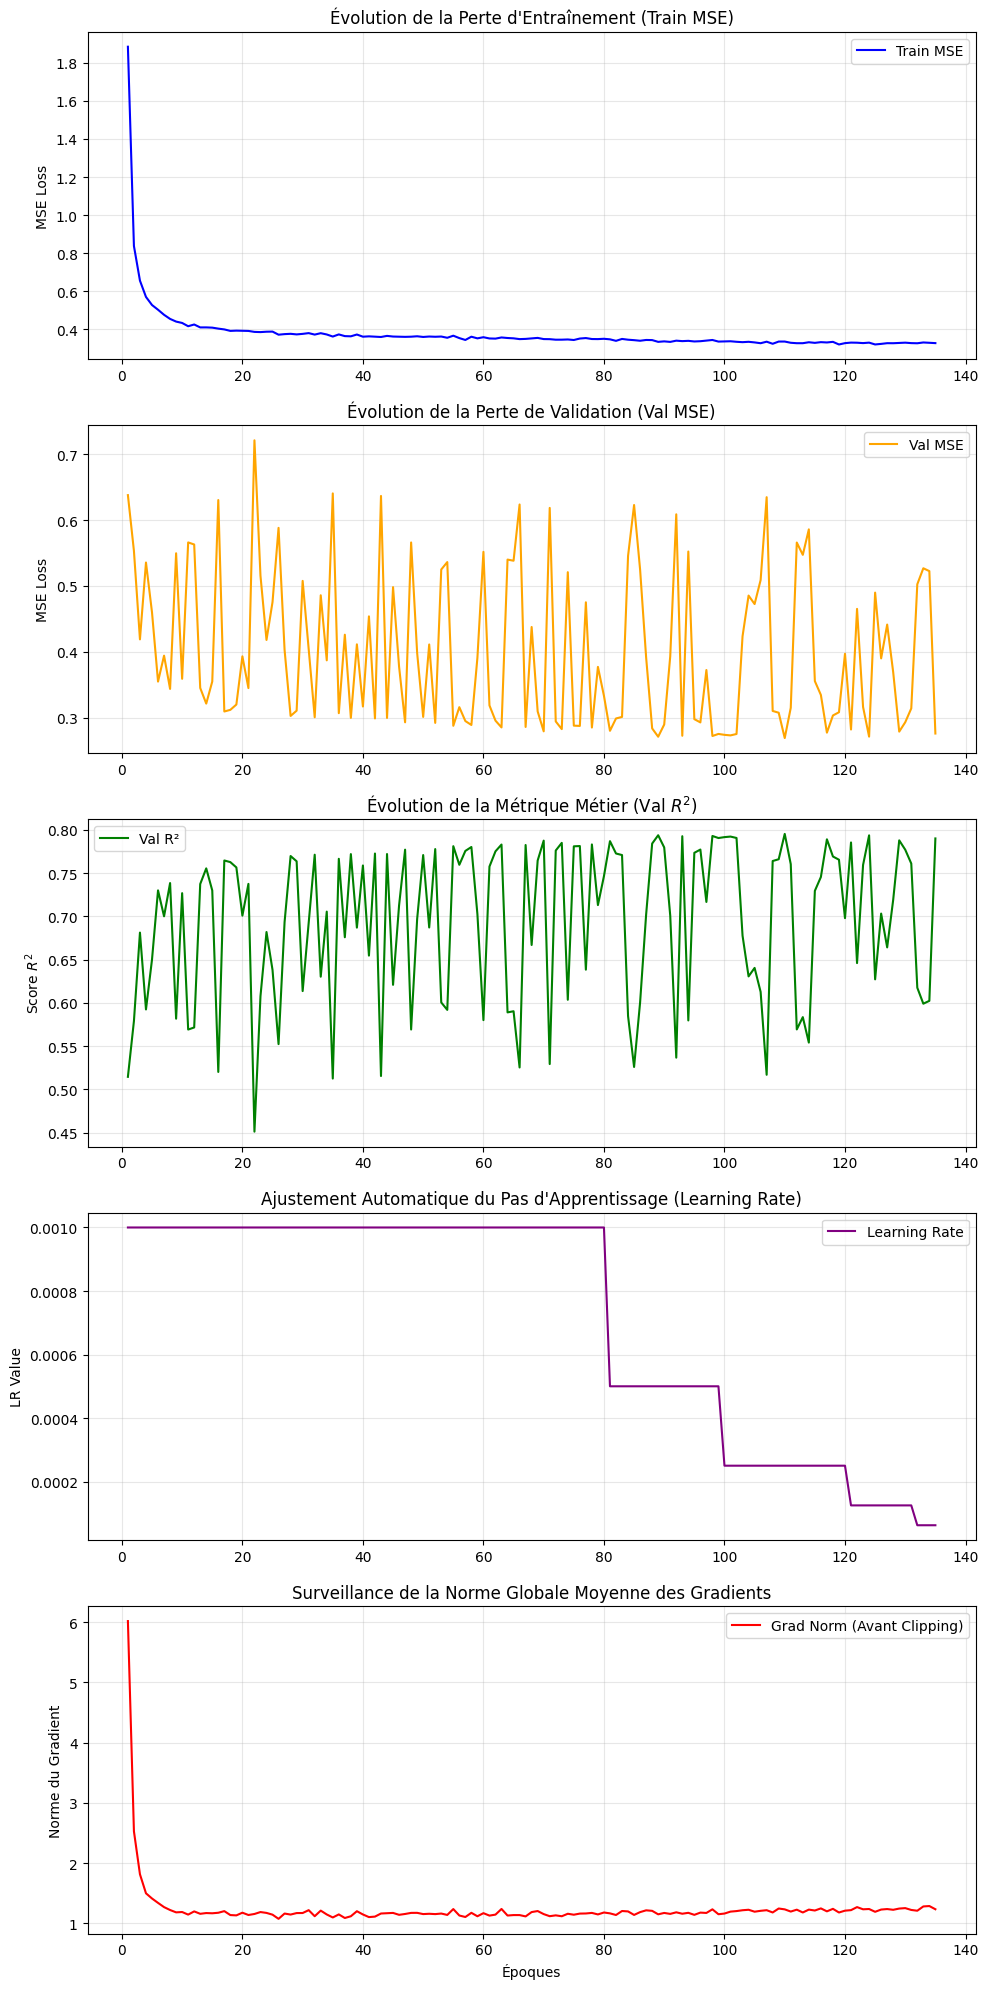

Graphique 'baseline_learning_curves.png' sauvegardé avec succès.


In [19]:
if __name__ == "__main__":
    # (Les tests de la Q3 se trouvent ici...)
    
    # =====================================================================
    # Question 7 : Entraînement et Visualisation du Modèle Baseline
    # =====================================================================
    print("\n=== Préparation de la Configuration Baseline ===")
    
    # 1. Définition stricte du dictionnaire de configuration exigé par l'énoncé
    config_baseline = {
        'hidden_dims': [128, 64, 32],      # Architecture à 3 couches cachées [cite: 253]
        'activation': 'relu',              # Fonction d'activation ReLU [cite: 254]
        'use_bn': True,                    # Activation de la Batch Normalization [cite: 255]
        'dropout_rate': 0.2,               # Taux de Dropout à 20% [cite: 256]
        'lr': 1e-3,                        # Taux d'apprentissage initial 
        'weight_decay': 1e-4,              # Pénalité L2 pour la régularisation [cite: 259]
        'clip_value': 1.0,                 # Seuil pour le Gradient Clipping 
        'epochs': 200,                     # Nombre maximum d'époques [cite: 261]
        'early_stopping_patience': 25      # Patience pour l'arrêt précoce [cite: 262]
    }
    
    # 2. Instanciation du modèle avec application rigoureuse de la graine aléatoire
    torch.manual_seed(42)  # Consigne de vigilance absolue [cite: 37, 562]
    model_baseline = DeepFFN(
        input_dim=8,
        hidden_dims=config_baseline['hidden_dims'],
        output_dim=1,
        activation=config_baseline['activation'],
        use_bn=config_baseline['use_bn'],
        dropout_rate=config_baseline['dropout_rate']
    )
    
    print("Lancement de l'apprentissage du modèle Baseline...")
    # Execution de la boucle d'entraînement complète (développée en Q6)
    history, best_mse, elapsed_time = train_model(
        model_baseline, 
        train_loader, 
        val_loader, 
        config_baseline
    )
    
    print(f"\n[Fin de l'Entraînement]")
    print(f"Meilleur score trouvé (Validation MSE) : {best_mse:.4f}")
    print(f"Temps de calcul total : {elapsed_time:.1f} secondes")
    
    # 3. Génération des 5 sous-graphes d'apprentissage demandés
    print("\nCréation et sauvegarde des courbes d'apprentissage...")
    fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=False)
    epochs_range = range(1, len(history['train_mse']) + 1)
    
    # Sous-graphe 1 : Évolution de la perte d'entraînement (Train MSE)
    axes[0].plot(epochs_range, history['train_mse'], color='blue', label='Train MSE')
    axes[0].set_title("Évolution de la Perte d'Entraînement (Train MSE)")
    axes[0].set_ylabel('MSE Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Sous-graphe 2 : Évolution de la perte de validation (Val MSE)
    axes[1].plot(epochs_range, history['val_mse'], color='orange', label='Val MSE')
    axes[1].set_title("Évolution de la Perte de Validation (Val MSE)")
    axes[1].set_ylabel('MSE Loss')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Sous-graphe 3 : Évolution du coefficient de détermination (Val R²)
    axes[2].plot(epochs_range, history['val_r2'], color='green', label='Val R²')
    axes[2].set_title("Évolution de la Métrique Métier (Val $R^2$)")
    axes[2].set_ylabel('Score $R^2$')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    # Sous-graphe 4 : Évolution dynamique du pas d'apprentissage (Learning Rate)
    axes[3].plot(epochs_range, history['lr'], color='purple', label='Learning Rate')
    axes[3].set_title("Ajustement Automatique du Pas d'Apprentissage (Learning Rate)")
    axes[3].set_ylabel('LR Value')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()
    
    # Sous-graphe 5 : Évolution de la norme moyenne des gradients (Grad Norm)
    axes[4].plot(epochs_range, history['grad_norm'], color='red', label='Grad Norm (Avant Clipping)')
    axes[4].set_title("Surveillance de la Norme Globale Moyenne des Gradients")
    axes[4].set_xlabel('Époques')
    axes[4].set_ylabel('Norme du Gradient')
    axes[4].grid(True, alpha=0.3)
    axes[4].legend()
    
    # Ajustement des espacements et sauvegarde au format PNG demandé
    plt.tight_layout()
    plt.savefig('baseline_learning_curves.png', dpi=120)  # Consigne stricte de rendu [cite: 565]
    plt.show()
    print("Graphique 'baseline_learning_curves.png' sauvegardé avec succès.")

In [22]:

# Q1 : Définition des 5 configurations de la table d'ablation
configs_ablation = {
    'A': {'use_bn': True,  'dropout_rate': 0.2, 'weight_decay': 1e-4, 'desc': 'Baseline complet (Référence)'},
    'B': {'use_bn': False, 'dropout_rate': 0.2, 'weight_decay': 1e-4, 'desc': 'Sans BatchNorm (Instabilité ?)'},
    'C': {'use_bn': True,  'dropout_rate': 0.0, 'weight_decay': 1e-4, 'desc': 'Sans Dropout (Surapprentissage ?)'},
    'D': {'use_bn': True,  'dropout_rate': 0.2, 'weight_decay': 0.0,  'desc': 'Sans L2 (Surapprentissage léger ?)'},
    'E': {'use_bn': False, 'dropout_rate': 0.0, 'weight_decay': 0.0,  'desc': 'Aucune régulation (Surapprentissage fort)'}
}

# Liste pour collecter les résultats finaux de la table
table_synthese = []
# Dictionnaire pour sauvegarder les historiques de pertes (essentiel pour la Q2)
histories_ablation = {}

print("=== Lancement de l'Exercice 3 - Question 1 : Table d'Ablation ===")

for name, cfg in configs_ablation.items():
    print(f"\n[Configuration {name}] Entraînement de : {cfg['desc']}...")
    
    # POINT DE VIGILANCE IMPÉRATIF : Appliquer la même seed de départ avant CHAQUE instanciation
    torch.manual_seed(42)
    
    # Création du modèle adapté aux choix d'ablation de la configuration
    model = DeepFFN(
        input_dim=8,
        hidden_dims=[128, 64, 32], # Architecture figée pour l'équité du test
        output_dim=1,
        activation='relu',
        use_bn=cfg['use_bn'],
        dropout_rate=cfg['dropout_rate']
    )
    
    # Hyperparamètres communs d'entraînement imposés par l'énoncé
    run_config = {
        'lr': 1e-3,
        'weight_decay': cfg['weight_decay'],
        'clip_value': 1.0,
        'epochs': 100,                     # Max 100 epochs
        'early_stopping_patience': 15      # Patience fixée à 15
    }
    
    # Exécution de la boucle d'apprentissage
    history, best_val_mse, temps_calcul = train_model(model, train_loader, val_loader, run_config)
    
    # Stockage de l'historique complet pour la future question 2
    histories_ablation[name] = history
    
    # Sauvegarde des données pour le tableau comparatif final
    table_synthese.append({
        'Modele': name,
        'Description': cfg['desc'],
        'Val MSE': best_val_mse,
        'Temps': temps_calcul
    })
    print(f"-> Résultat {name} : Best Val MSE = {best_val_mse:.4f} | Temps = {temps_calcul:.1f}s")

# Affichage formaté du tableau exigé par le professeur
print("\n" + "="*75)
print(f"{'Modèle/Config':<12} | {'Description':<38} | {'Val MSE':<10} | {'Temps total':<10}")
print("="*75)
for row in table_synthese:
    print(f"Config {row['Modele']:<5} | {row['Description']:<38} | {row['Val MSE']:<10.4f} | {row['Temps']:<10.1f}s")
print("="*75)

=== Lancement de l'Exercice 3 - Question 1 : Table d'Ablation ===

[Configuration A] Entraînement de : Baseline complet (Référence)...
Ep [ 20] | tr MSE=0.3910 | val MSE=0.3929 | R²=0.7009 | lr=0.001000
Ep [ 40] | tr MSE=0.3598 | val MSE=0.3168 | R²=0.7589 | lr=0.001000
Ep [ 60] | tr MSE=0.3570 | val MSE=0.5517 | R²=0.5801 | lr=0.001000
Ep [ 80] | tr MSE=0.3488 | val MSE=0.3330 | R²=0.7465 | lr=0.001000
 Early stopping à l'epoch 85
-> Résultat A : Best Val MSE = 0.2791 | Temps = 71.3s

[Configuration B] Entraînement de : Sans BatchNorm (Instabilité ?)...
Ep [ 20] | tr MSE=0.3602 | val MSE=0.3141 | R²=0.7609 | lr=0.001000
Ep [ 40] | tr MSE=0.3226 | val MSE=0.2899 | R²=0.7793 | lr=0.001000
Ep [ 60] | tr MSE=0.2969 | val MSE=0.2722 | R²=0.7929 | lr=0.000500
 Early stopping à l'epoch 78
-> Résultat B : Best Val MSE = 0.2699 | Temps = 48.8s

[Configuration C] Entraînement de : Sans Dropout (Surapprentissage ?)...
Ep [ 20] | tr MSE=0.2996 | val MSE=0.6468 | R²=0.5077 | lr=0.001000
Ep [ 40] |


=== Exécution de la Question 2 : Tracés des paires comparatives ===


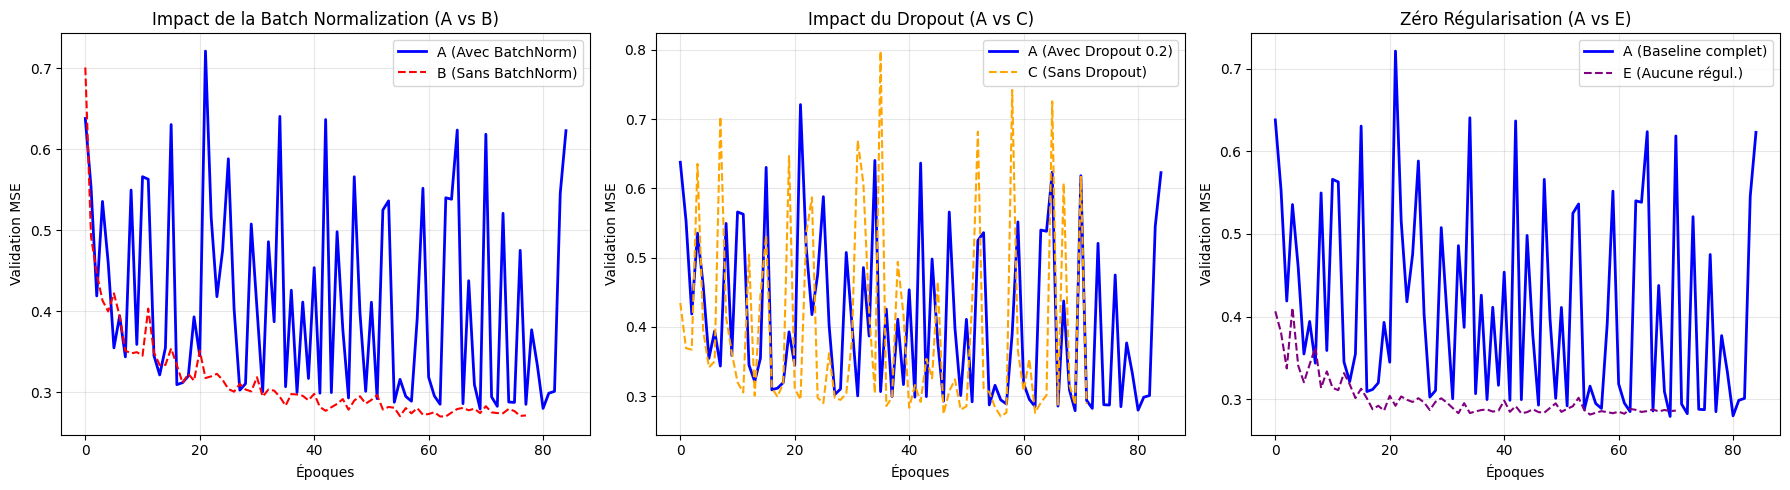

Graphique 'ablation_study_curves.png' sauvegardé avec succès.


In [23]:


print("\n=== Exécution de la Question 2 : Tracés des paires comparatives ===")

# Création d'une figure contenant 3 sous-graphes alignés horizontalement
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --------------------------------------------------------------------------
# Graphique 1 : A vs B — L'impact de la Batch Normalization
# --------------------------------------------------------------------------
axes[0].plot(histories_ablation['A']['val_mse'], label='A (Avec BatchNorm)', color='blue', linewidth=2)
axes[0].plot(histories_ablation['B']['val_mse'], label='B (Sans BatchNorm)', color='red', linestyle='--')
axes[0].set_title('Impact de la Batch Normalization (A vs B)')
axes[0].set_xlabel('Époques')
axes[0].set_ylabel('Validation MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --------------------------------------------------------------------------
# Graphique 2 : A vs C — L'impact du Dropout
# --------------------------------------------------------------------------
axes[1].plot(histories_ablation['A']['val_mse'], label='A (Avec Dropout 0.2)', color='blue', linewidth=2)
axes[1].plot(histories_ablation['C']['val_mse'], label='C (Sans Dropout)', color='orange', linestyle='--')
axes[1].set_title('Impact du Dropout (A vs C)')
axes[1].set_xlabel('Époques')
axes[1].set_ylabel('Validation MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --------------------------------------------------------------------------
# Graphique 3 : A vs E — L'impact d'une absence totale de régularisation
# --------------------------------------------------------------------------
axes[2].plot(histories_ablation['A']['val_mse'], label='A (Baseline complet)', color='blue', linewidth=2)
axes[2].plot(histories_ablation['E']['val_mse'], label='E (Aucune régul.)', color='purple', linestyle='--')
axes[2].set_title('Zéro Régularisation (A vs E)')
axes[2].set_xlabel('Époques')
axes[2].set_ylabel('Validation MSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Ajustement automatique des espaces et sauvegarde au format PNG réglementaire (DPI=120)
plt.tight_layout()
plt.savefig('ablation_study_curves.png', dpi=120) # Respect strict de la consigne du TP
plt.show()

print("Graphique 'ablation_study_curves.png' sauvegardé avec succès.")


=== Lancement de l'Exercice 3 - Question 3 : Effet du Gradient Clipping ===
-> Expérimentation en cours : Sans clipping pendant 50 époques...
Ep [ 20] | tr MSE=0.4201 | val MSE=0.3997 | R²=0.6958 | lr=0.001000
Ep [ 40] | tr MSE=0.3683 | val MSE=0.3190 | R²=0.7572 | lr=0.001000
-> Expérimentation en cours : clip = 0.1 pendant 50 époques...
Ep [ 20] | tr MSE=0.3909 | val MSE=0.3953 | R²=0.6991 | lr=0.001000
Ep [ 40] | tr MSE=0.3593 | val MSE=0.3143 | R²=0.7608 | lr=0.001000
-> Expérimentation en cours : clip = 0.5 pendant 50 époques...
Ep [ 20] | tr MSE=0.3926 | val MSE=0.3858 | R²=0.7064 | lr=0.001000
Ep [ 40] | tr MSE=0.3586 | val MSE=0.3168 | R²=0.7589 | lr=0.001000
-> Expérimentation en cours : clip = 1.0 pendant 50 époques...
Ep [ 20] | tr MSE=0.3910 | val MSE=0.3929 | R²=0.7009 | lr=0.001000
Ep [ 40] | tr MSE=0.3598 | val MSE=0.3168 | R²=0.7589 | lr=0.001000
-> Expérimentation en cours : clip = 5.0 pendant 50 époques...
Ep [ 20] | tr MSE=0.4093 | val MSE=0.3963 | R²=0.6984 | lr=0.

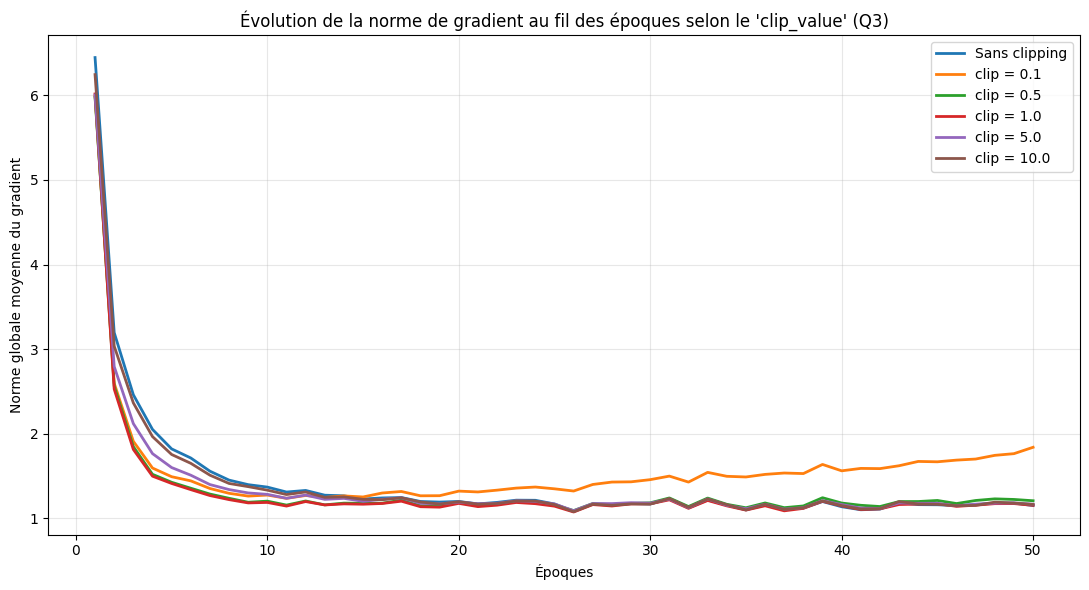

Graphique 'gradient_clipping_curves.png' sauvegardé avec succès.


In [26]:


print("\n=== Lancement de l'Exercice 3 - Question 3 : Effet du Gradient Clipping ===")

# Q3 : Liste des valeurs de clip_value à tester
clip_values = [float('inf'), 0.1, 0.5, 1.0, 5.0, 10.0]

# Dictionnaire pour enregistrer les historiques des normes de gradient pour chaque test
clipping_histories = {}

for clip in clip_values:
    # Label propre pour l'affichage et les graphiques
    clip_label = 'Sans clipping' if clip == float('inf') else f'clip = {clip}'
    print(f"-> Expérimentation en cours : {clip_label} pendant 50 époques...")
    
    # POINT DE VIGILANCE : Réinitialisation stricte de la seed avant chaque instanciation (Consigne)
    torch.manual_seed(42)
    
    # Création du modèle complet basé sur l'architecture Baseline
    model = DeepFFN(
        input_dim=8,
        hidden_dims=[128, 64, 32],
        output_dim=1,
        activation='relu',
        use_bn=True,
        dropout_rate=0.2
    )
    
    # Configuration figée à 50 époques sans Early Stopping pour enregistrer l'intégralité du comportement
    clip_config = {
        'lr': 1e-3,
        'weight_decay': 1e-4,
        'clip_value': clip,
        'epochs': 50,                      # Entraîner exactement 50 époques
        'early_stopping_patience': 999     # On désactive l'early stopping pour ce test
    }
    
    # Exécution de l'entraînement
    history, _, _ = train_model(model, train_loader, val_loader, clip_config)
    
    # On mémorise uniquement le suivi de la norme du gradient époque par époque
    clipping_histories[clip_label] = history['grad_norm']

# --- Génération du graphique de la Question 3 ---
plt.figure(figsize=(11, 6))

for label, grad_norms in clipping_histories.items():
    plt.plot(range(1, 51), grad_norms, label=label, linewidth=2)

plt.xlabel('Époques')
plt.ylabel('Norme globale moyenne du gradient')
plt.title("Évolution de la norme de gradient au fil des époques selon le 'clip_value' (Q3)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_clipping_curves.png', dpi=120) # Sauvegarde au format PNG demandé (DPI=120)
plt.show()

print("Graphique 'gradient_clipping_curves.png' sauvegardé avec succès.")

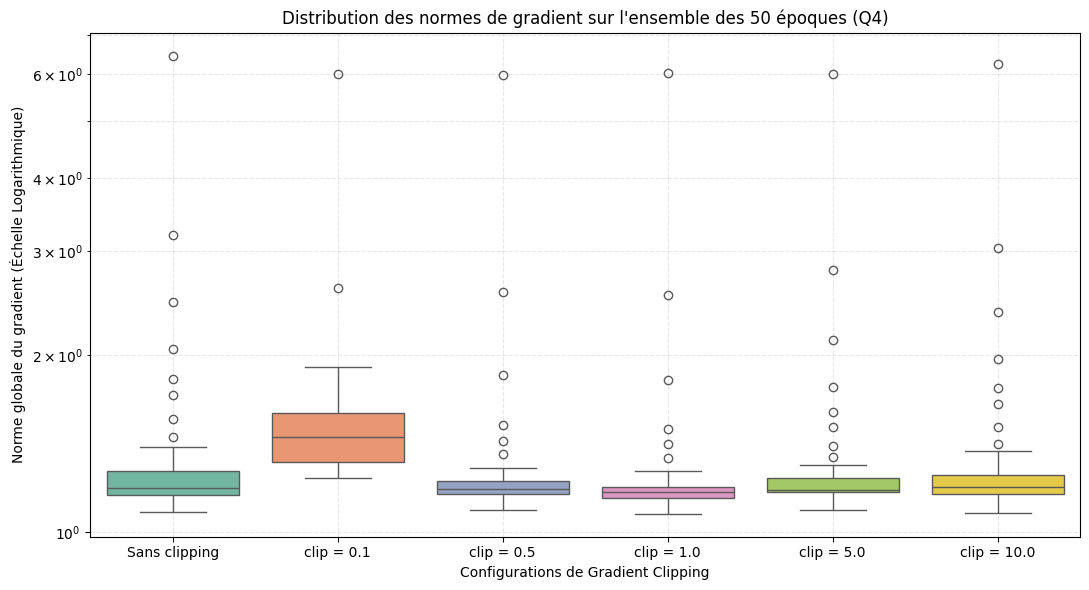

Graphique 'gradient_clipping_distributions.png' sauvegardé avec succès.


In [27]:


# 1. Transformation du dictionnaire d'historiques en DataFrame Pandas
# Chaque colonne correspondra à un paramètre de clipping testé sur les 50 époques
df_gradients = pd.DataFrame(clipping_histories)

# 2. Création de la figure pour le Boxplot
plt.figure(figsize=(11, 6))

# On utilise une échelle logarithmique sur l'axe Y car les écarts de grandeur 
# entre "clip = 0.1" et "Sans clipping" peuvent être gigantesques (plusieurs ordres de grandeur)
sns.boxplot(data=df_gradients, palette="Set2")
plt.yscale('log')

plt.xlabel("Configurations de Gradient Clipping")
plt.ylabel("Norme globale du gradient (Échelle Logarithmique)")
plt.title("Distribution des normes de gradient sur l'ensemble des 50 époques (Q4)")
plt.grid(True, which="both", linestyle="--", alpha=0.3)

# Ajustement et sauvegarde réglementaire au format PNG (DPI=120)
plt.tight_layout()
plt.savefig('gradient_clipping_distributions.png', dpi=120) # Consigne du TP
plt.show()

print("Graphique 'gradient_clipping_distributions.png' sauvegardé avec succès.")


[Expérience A] Entraînement sur données brutes SANS gradient clipping...
Ep [ 20] | tr MSE=0.5578 | val MSE=0.5175 | R²=0.6062 | lr=0.001000

[Expérience B] Entraînement sur données brutes AVEC gradient clipping (clip = 1.0)...
Ep [ 20] | tr MSE=0.6144 | val MSE=0.6307 | R²=0.5200 | lr=0.001000


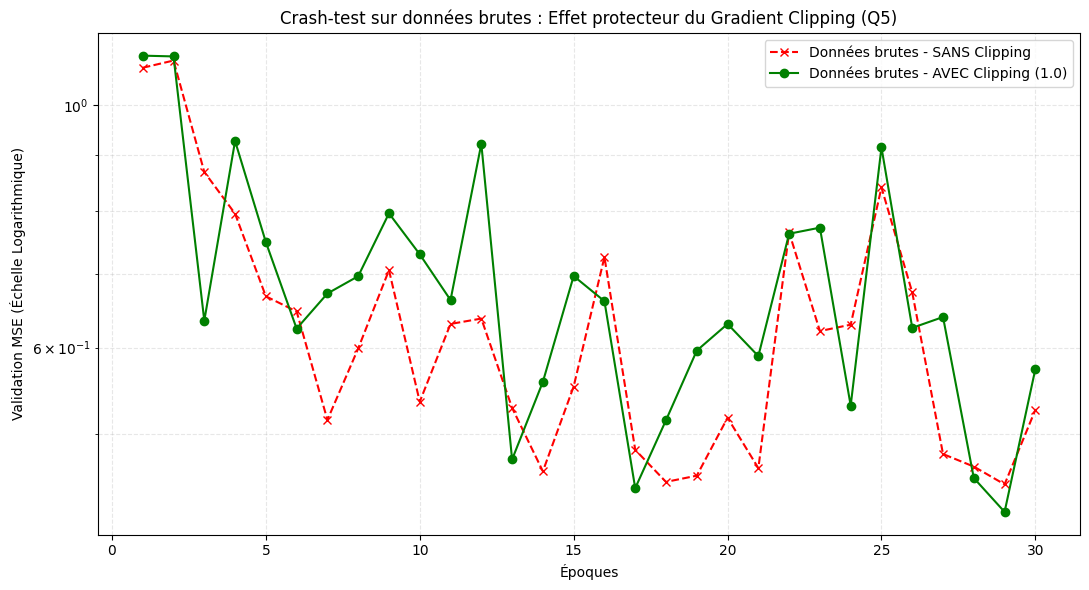

Graphique 'gradient_clipping_crash_test.png' généré avec succès.


In [28]:

train_raw_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), 
    torch.tensor(y_train, dtype=torch.float32)
)
val_raw_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32), 
    torch.tensor(y_val, dtype=torch.float32)
)

train_raw_loader = DataLoader(train_raw_ds, batch_size=64, shuffle=True)
val_raw_loader   = DataLoader(val_raw_ds, batch_size=256, shuffle=False)

# Configuration de test fixée à 30 époques sans early stopping pour observer le comportement brut
raw_test_config = {
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 30,
    'early_stopping_patience': 999
}

# --- Expérience A : Données brutes SANS clipping ---
print("\n[Expérience A] Entraînement sur données brutes SANS gradient clipping...")
torch.manual_seed(42)  # Reproductibilité stricte
model_no_clip = DeepFFN(input_dim=8, hidden_dims=[128, 64, 32], output_dim=1, activation='relu', use_bn=True, dropout_rate=0.2)

config_no_clip = {**raw_test_config, 'clip_value': float('inf')}
history_no_clip, _, _ = train_model(model_no_clip, train_raw_loader, val_raw_loader, config_no_clip)

# --- Expérience B : Données brutes AVEC clipping (clip = 1.0) ---
print("\n[Expérience B] Entraînement sur données brutes AVEC gradient clipping (clip = 1.0)...")
torch.manual_seed(42)  # Même graine pour une comparaison scientifique honnête
model_with_clip = DeepFFN(input_dim=8, hidden_dims=[128, 64, 32], output_dim=1, activation='relu', use_bn=True, dropout_rate=0.2)

config_with_clip = {**raw_test_config, 'clip_value': 1.0}
history_with_clip, _, _ = train_model(model_with_clip, train_raw_loader, val_raw_loader, config_with_clip)

# --- Génération du graphique comparatif de la Question 5 ---
plt.figure(figsize=(11, 6))

plt.plot(range(1, 31), history_no_clip['val_mse'], label='Données brutes - SANS Clipping', color='red', linestyle='--', marker='x')
plt.plot(range(1, 31), history_with_clip['val_mse'], label='Données brutes - AVEC Clipping (1.0)', color='green', linestyle='-', marker='o')

plt.yscale('log')  # Utilisation de l'échelle log car les pertes sans clipping s'envolent vers l'infini
plt.xlabel('Époques')
plt.ylabel('Validation MSE (Échelle Logarithmique)')
plt.title('Crash-test sur données brutes : Effet protecteur du Gradient Clipping (Q5)')
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_clipping_crash_test.png', dpi=120)  # Sauvegarde réglementaire PNG (DPI=120)
plt.show()

print("Graphique 'gradient_clipping_crash_test.png' généré avec succès.")